<a href="https://colab.research.google.com/github/Rybus07/in-a-pickle/blob/main/notebooks/01_data_wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction<a id='introduction'></a>

**Purpose:**

Clean and explore data with univariate, bivariate plots

**Context:**

&emsp; Pickleball is an addictively fun racquet sport combining aspects of tennis, table tennis, and badminton and pickleball players are similarly diverse with players of all ages and all sports backgrounds. Players often spend hours on the courts both playing and socializing between games. A common topic of discussion amongst players is strategy with questions such as

* "Should I be dropping or driving my third shots?"
* "What kind of shots are more common at higher levels of play?"

This project aims to answer common questions in pickleball using data from pklmart.

**Data:**

Collection of pklmart data on Kaggle (https://www.kaggle.com/datasets/cakesofspan/pklmarts-competitive-pickleball-extracts). \
Pklmart (https://pklmart.com/)

**Outcomes from this notebook (Data Wrangling):**

1. Data were explored and cleaned where necessary. Remaining NaNs are largely inconsequential.
2. Merged shot.csv with rally.csv to create a master dataframe at the shot level. File is saved under shot_rally.csv and a script was created to recreate the file from the command line.
3. Plotted univariate and bivariate distributions
    * Distributions showed trends in skill_lvl where players with skill_lvl of 4.5 and above played similarly and could be grouped into a larger class called 'Advanced'
    * Saw that cardinality of `shot_type` was high and needed to be reduced


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Andy's path to project data folder
data_path = '/content/drive/MyDrive/Colab Notebooks/DSCI 521 Final Project (Pickleball Analytics)/data/'

plt.rcParams.update({'font.size': 16})

## To-Do:

1. Can we make an estimate of how a game may have gone differently if a player chooses to be more or less aggressive?
2. Looking at distribution of winner, error, unforced error according to shot type
3. Distribution of next shot vs current shot, and distribution of next 2 shots (would be your next shot) vs current shot (Split accourding to DUPR)
4. Clean data
5. Create master dataframe to do most of analysis

Method:
1. First create a history of shots and outcomes for a given player.
2. Establish profile of aggressive/defensive  by considering the shots choices made by the player.
3. Tune player shot profile to be more aggressive/defensive, then simulate games using history of shots.
4. Compare results of simulations for more aggressive/defensive playstyles.
5. Understand data

## Contents<a id='contents'></a>
* [Introduction](#introduction)
* [Contents](#contents)
* [Objectives](#objectives)
* [Cleaning Data](#cleaning_data)
* [Detailed Outcomes](#detailed_outcomes)

## Objectives

1. Load and make sense of pklmart data
2. Clean pklmart data
3. Establish clear project objective
4. Figure out project endpoint and deliverable

## Cleaning Data<a id='cleaning_data'></a>

Data comes from pklmart, hosted on Kaggle. Includes 7 tables.


In [ ]:
game_df = pd.read_csv(data_path+'raw/game.csv')
player_df = pd.read_csv(data_path+'raw/player.csv')
team_df = pd.read_csv(data_path+'raw/team.csv')
rally_df = pd.read_csv(data_path+'raw/rally.csv')
shot_df = pd.read_csv(data_path+'raw/shot.csv')
shot_type_ref = pd.read_csv(data_path+'raw/shot_type_ref.csv')

### Game Data<a id='game_data'></a>

Missing 0.107% of `ball_type` data. Since ball type has a minor effect match, will not be concerned with this field

**Result:**
* Game data is largely clean

In [ ]:
print(game_df.shape)
game_df.head()

(935, 11)


,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21
3,G107,M54,1,11,4,T78,T82,4.5,STANDARD_DOUBLES,U,2023-02-25
4,G104,M52,1,11,5,T78,T79,4.5,STANDARD_DOUBLES,U,2023-02-25


In [ ]:
game_df.isnull().sum()/game_df.shape[0]*100

game_id         0.000000
match_id        0.000000
game_nbr        0.000000
score_w         0.000000
score_l         0.000000
w_team_id       0.000000
l_team_id       0.000000
skill_lvl       0.000000
scoring_type    0.000000
ball_type       0.106952
dt_played       0.000000
dtype: float64

In [ ]:
print('Number of unique game IDs: ',game_df['game_id'].nunique())

Number of unique game IDs:  935


### Player Data<a id='player_data'></a>

Missing 0.217% of data for `gender, dom_hand` \
Missing 59.7% of data for `doublesreliabilityscore` \
Missing 60.0% of data for `doubles_dupr`

**Result:**
* Missing 60.0% of data for `doubles_dupr` and only 29.1% of players have a `doubles_dupr` with a reliability score over 50
  * Can try to impute missing dupr scores by taking an average or mode from their games

In [ ]:
print(player_df.shape)
player_df.head()

(923, 5)


,player_id,gender,dom_hand,doubles_dupr,doublesreliabilityscore
0,P699,M,L,NaN,NaN
1,P600,M,R,4.101,5.0
2,P472,M,R,NaN,NaN
3,P320,M,R,NaN,0.0
4,P290,M,L,3.967,1.0


In [ ]:
player_df.isnull().sum()/player_df.shape[0]*100

player_id                   0.000000
gender                      0.216685
dom_hand                    0.216685
doubles_dupr               60.021668
doublesreliabilityscore    59.696641
dtype: float64

In [ ]:
player_df[player_df['doublesreliabilityscore'] > 50].shape[0]/player_df.shape[0]*100

29.144095341278444

C:\Users\kimvo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='doubles_dupr', ylabel='Count'>

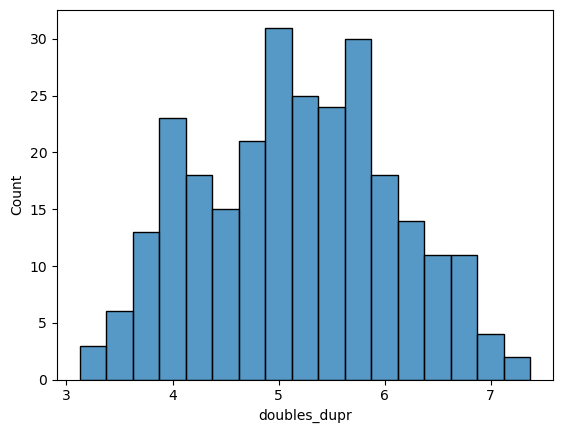

In [ ]:
sns.histplot(player_df[player_df['doublesreliabilityscore'] > 50], x='doubles_dupr', binwidth=0.25)

### Team Data<a id='team_data'></a>

Team data does not contain null values

In [ ]:
print(team_df.shape)
team_df.head()

(1590, 3)


,team_id,player_id,player_seq_nbr
0,T3,P5,1
1,T3,P2,2
2,T5,P8,1
3,T5,P9,2
4,T7,P12,1


In [ ]:
team_df.isnull().sum()/team_df.shape[0]*100

team_id           0.0
player_id         0.0
player_seq_nbr    0.0
dtype: float64

### Rally Data<a id='rally_data'></a>

Missing 0.931% of data in `w_team_id, srv_player_id, rtrn_player_id, srv_team_flipped_ind, rtrn_team_flipped_ind` \
Missing 1.25% of data in `rally_len` \
Missing 8.06% of data in `ts_type` \
Missing 8.90% of data in `ending_player_id` \
Missing 20.3% of data in `ts_player_id` \
Missing 99.1% of data in `to_team_id`


**Result:**
* Fields with 0.931% of missing data are from the same records
  * Explore if those data are compromised, but likely can drop these rallies
* Try to fill in missing `rally_len` by consulting shot data
* Try to fill in missing `ts_type` by consulting shot data
* Missing data in `ts_player_id` and `to_team_id` are not concerning

In [ ]:
print(rally_df.shape)
rally_df.head()

(40702, 24)


,rally_id,game_id,match_id,rally_nbr,w_team_id,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,...,ending_type,ending_player_id,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,G208,M113,6,T152,T152,P202,T155,P70,P202,...,Other,NaN,Y,N,N,N,P203,P202,P70,P205
1,R8963,G208,M113,1,T155,T152,P202,T155,P70,NaN,...,Error,P203,Y,N,N,N,P203,P202,P70,P205
2,R8964,G208,M113,2,T152,T155,P70,T152,P202,P205,...,Error,P205,N,Y,N,N,P70,P205,P203,P202
3,R8965,G208,M113,3,T155,T155,P205,T152,P203,P205,...,Error,P203,N,Y,N,N,P70,P205,P203,P202
4,R8966,G208,M113,4,T155,T155,P205,T152,P202,P70,...,Winner,P205,Y,Y,Y,N,P70,P205,P203,P202


In [ ]:
rally_df.isnull().sum()/rally_df.shape[0]*100

,0
rally_id,0.000000
game_id,0.000000
match_id,0.000000
rally_nbr,0.000000
w_team_id,0.931158
srv_team_id,0.000000
srv_player_id,0.931158
rtrn_team_id,0.000000
rtrn_player_id,0.931158
ts_player_id,20.342981


In [ ]:
rally_df['ts_type'].value_counts()

,count
ts_type,
Drop,20152
Drive,16660
Lob,608


<Axes: >

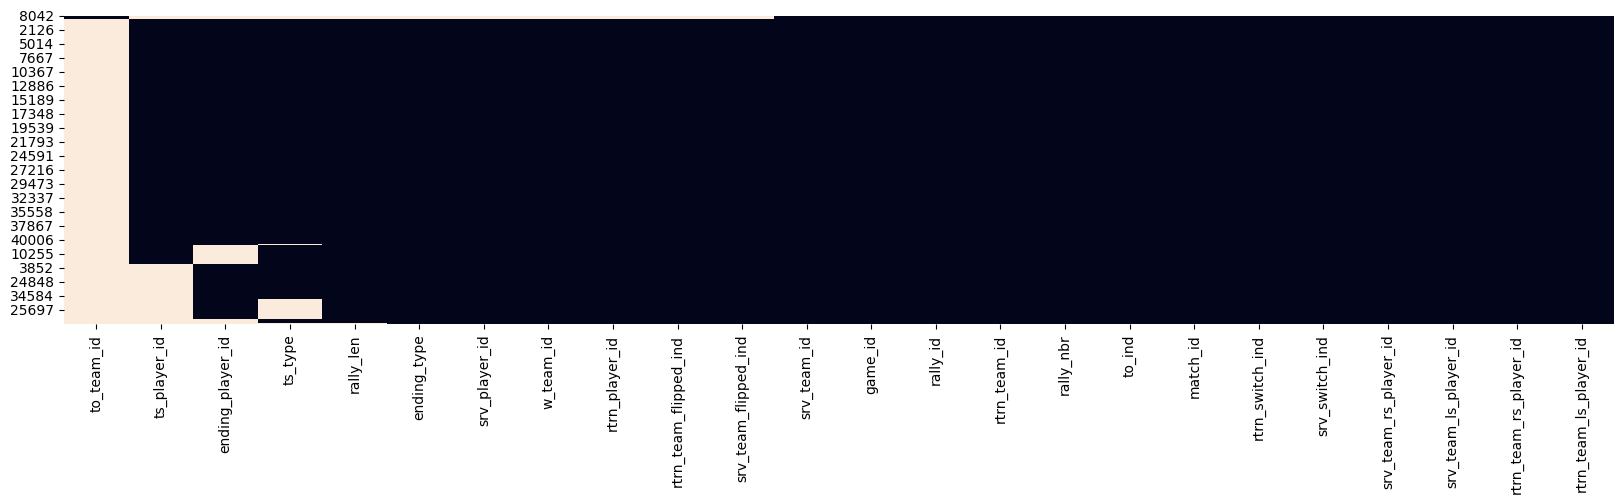

In [ ]:
cols=list(rally_df.notnull().sum().sort_values().index)
plt.figure(figsize=(20,4))
sns.heatmap(rally_df[cols].isnull().sort_values(by=cols), cbar=False)

### Shot Data<a id='shot_data'></a>

Missing 0.004% of `shot_type` \
Missing 0.025% of `player_id` \
Missing 0.028% of `loc_y` \
Missing 4.02% of `next_loc_x, next_loc_y`

**Result:**
* Explore why missing data for `next_loc_x, next_loc_y`
* Explore why missing data for `loc_y` but not for `loc_x`
* Try to fill in `shot_type` by looking at `next_loc_x, next_loc_y`
* Data is relatively clean but see if we can fill in some missing values

**Steps for Cleaning**

Note: Code does not reflect the order below

1. Load shot and rally data
2. Merge with rally data. Then sort and reset index
   Columns to merge = [rally_id, game_id, match_id, rally_nbr,
   rally_len, w_team_id, srv_team_id, rtrn_team_id, ending_type]
3. Remove edge cases
    * Remove any rallies with a missed serve. Identified where rally_len == 1 and loc_y is NaN
4. Fill NaNs
    * Fill NaNs in loc_y
        * Backfill NaN in loc_y using next_loc_y from previous shot
            Note: Since step 2 removes rallies with a missing serve
            (loc_y == NaN and rally_len == 1), all NaNs in loc_y
            will have a previous shot. This will also handle all NaNs in loc_y
    * Fill NaNs in next_loc_x, next_loc_y using next shot if present
        Note: remaining NaNs can now be assumed to be at the end of a rally
    * Fill NaNs in shot_type with U for unknown
5. Remove incomplete rallies. Identified where max(shot_nbr) != rally_len
6. Adding additional columns
    * add shot_outcome MAKE SURE DATAFRAME IS IN DESCENDING ORDER OF SHOT NBR
    * add rally_outcome MAKE SURE DATAFRAME IS IN DESCENDING ORDER OF SHOT NBR
    * Calculate change in position for both x, y coordinates
    * Add shot angle column
    * Calculate distance from kitchen line
7. Fill additional NaNs
    * Fill NaNs in ending_type, shot_outcome, and shot_type
8. Change coordinate system
9. Standardize court coordinate system
10. Save

In [ ]:
shot_df = pd.read_csv(data_path+'raw/shot.csv')
print(shot_df.shape)
shot_df.head()

(304649, 9)


,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S213113,R26079,2,R,P582,18.35,23.70,18.64,21.59
1,S237646,R29288,3,tsDrv,P670,13.68,21.77,11.84,0.00
2,S213112,R26079,1,SE,P197,13.40,22.32,18.35,23.70
3,S213152,R26086,1,SE,P488,5.60,22.97,3.29,24.25
4,S213210,R26092,2,R,P488,5.50,20.58,9.81,12.03


In [ ]:
shot_df.isnull().sum()/shot_df.shape[0]*100

,0
shot_id,0.000000
rally_id,0.000000
shot_nbr,0.000000
shot_type,0.003939
player_id,0.024947
loc_x,0.000000
loc_y,0.027573
next_loc_x,4.020036
next_loc_y,4.020036


Now doing the actual cleaning.

First re-sort `shot_df` according to `rally_id, shot_nbr` and assigning new index.

Next, filling in null values for `loc_y`

In [ ]:
# Step 1
shot_df = pd.read_csv(data_path+'raw/shot.csv')

shot_df.sort_values(['rally_id', 'shot_nbr'], inplace=True)
shot_df.reset_index(drop=True, inplace=True)

In [ ]:
shot_df.head(10)

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S10554,R1000,1,SE,P13,16.74,20.17,15.82,22.80
1,S10555,R1000,2,R,P6,15.82,22.80,3.11,20.85
2,S10556,R1000,3,tsDrp,P23,3.11,20.85,7.12,7.56
3,S10557,R1000,4,tzRep,P6,7.12,7.56,8.72,18.56
4,S10558,R1000,5,tzApp,P13,8.72,18.56,5.86,7.79
5,S10559,R1000,6,HB,P24,5.86,7.79,-2.40,16.16
6,S10560,R1000,7,tzApp,P23,-2.40,16.16,15.14,8.82
7,S10561,R1000,8,HB,P24,15.14,8.82,3.33,19.48
8,S10562,R1000,9,HB,P23,3.33,19.48,NaN,NaN
9,S91499,R10000,1,SE,P256,8.07,21.95,5.32,20.03


In [ ]:
my_df = shot_df[shot_df['loc_y'].isnull()]
my_df[my_df['shot_nbr'] == 1]

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
68671,S168432,R20417,1,SE,P479,10.0,NaN,NaN,NaN


In [ ]:
# for rally_id R20417, setting loc_y to 23.0, outcome was unforced error.
# server likely missed the serve
my_ind = my_df[my_df['shot_nbr'] == 1].index
my_df.loc[my_ind, 'loc_y'] = 23.0
shot_df.loc[my_ind, 'loc_y'] = 23.0

Going through each rally where `loc_y` is null and seeing if can extract position from previous rally

In [ ]:
my_df = shot_df[shot_df['loc_y'].isnull()]

In [ ]:
my_df.index

Index([ 15744,  17234,  17910,  17930,  22932,  23219,  52649,  52807,  55582,
        58417,  58427,  58430,  58442,  58528,  58560,  59416,  60373,  62492,
        62932,  62995,  63083,  64962,  65139,  65310,  66554,  68812,  85988,
        86012,  86760,  88632, 110844, 115018, 116299, 118318, 127015, 127502,
       127768, 134784, 134830, 135813, 136175, 155612, 165416, 175456, 176595,
       203486, 281310, 285438, 287741, 287743, 287745, 287833, 287938, 292717,
       292718, 292719, 292720, 292721, 292722, 292723, 292724, 292822, 292823,
       292824, 292825, 292826, 292827, 292828, 292829, 292830, 292831, 292975,
       292976, 292977, 293189, 293190, 293191, 293192, 293193, 293289, 293353,
       297210, 302498],
      dtype='int64')

In [ ]:
shot_df.head(10)

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S10554,R1000,1,SE,P13,16.74,20.17,15.82,22.80
1,S10555,R1000,2,R,P6,15.82,22.80,3.11,20.85
2,S10556,R1000,3,tsDrp,P23,3.11,20.85,7.12,7.56
3,S10557,R1000,4,tzRep,P6,7.12,7.56,8.72,18.56
4,S10558,R1000,5,tzApp,P13,8.72,18.56,5.86,7.79
5,S10559,R1000,6,HB,P24,5.86,7.79,-2.40,16.16
6,S10560,R1000,7,tzApp,P23,-2.40,16.16,15.14,8.82
7,S10561,R1000,8,HB,P24,15.14,8.82,3.33,19.48
8,S10562,R1000,9,HB,P23,3.33,19.48,NaN,NaN
9,S91499,R10000,1,SE,P256,8.07,21.95,5.32,20.03


In [ ]:
# All shots where loc_y is null contain a previous shot.
# Pulling loc_y from next_loc_y of previous shot
inds = my_df.index

for i in inds:
    shot_df.loc[i, 'loc_y'] = shot_df.loc[i-1, 'next_loc_y']

In [ ]:
shot_df.isnull().sum()

,0
shot_id,0
rally_id,0
shot_nbr,0
shot_type,12
player_id,76
loc_x,0
loc_y,0
next_loc_x,12247
next_loc_y,12247


Now filling in nans for `next_loc_x, next_loc_y`

nans for `next_loc_x, next_loc_y` are in pairs, if nan for one then nan for other

In [ ]:
m1 = shot_df['next_loc_x'].isnull()
m2 = shot_df['next_loc_y'].isnull()

mask = [(x or y) for x,y in zip(m1, m2)]
my_df = shot_df[mask]

In [ ]:
my_df

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
8,S10562,R1000,9,HB,P23,3.33,19.48,NaN,NaN
18,S91508,R10000,10,HB,P194,-1.48,14.70,NaN,NaN
55,S91548,R10004,7,HB,P194,15.60,2.85,NaN,NaN
60,S91553,R10005,5,HB,P197,4.39,1.65,NaN,NaN
107,S10591,R1001,29,HB,P13,15.14,1.26,NaN,NaN
...,...,...,...,...,...,...,...,...,...
304575,S10553,R999,24,D,P24,15.02,1.72,NaN,NaN
304583,S91427,R9990,8,HB,P197,-1.75,2.94,NaN,NaN
304629,S91478,R9996,9,HB,P197,11.93,21.59,NaN,NaN
304642,S91492,R9998,8,HB,P257,4.40,1.38,NaN,NaN


In [ ]:
# for each pair of nans, check to see if there is a valid subsequent shot
# if there is, then pull values from there
inds = my_df.index

for i in inds:
    if i+1 < len(shot_df):
        if (shot_df.loc[i+1, 'shot_nbr'] == shot_df.loc[i, 'shot_nbr'] + 1):
            shot_df.loc[i, 'next_loc_x'] = shot_df.loc[i+1, 'loc_x']
            shot_df.loc[i, 'next_loc_y'] = shot_df.loc[i+1, 'loc_y']

In [ ]:
# remaining nans should be from last shots, double check that this is true
m1 = shot_df['next_loc_x'].isnull()
m2 = shot_df['next_loc_y'].isnull()

mask = [(x or y) for x,y in zip(m1, m2)]
my_df = shot_df[mask]

In [ ]:
inds = my_df.index
last_shot = []

for i in inds:
    if i + 1 < len(shot_df):
        if shot_df.loc[i, 'rally_id'] != shot_df.loc[i+1, 'rally_id']:
            last_shot.append(True)
        else:
            last_shot.append(False)

In [ ]:
# yes, all remaining nans on next_loc_x, next_loc_y are found in the last shot
print(len(my_df), sum(last_shot))

11818 11817


In [ ]:
# saving progress
shot_df.to_csv(data_path+'interim/shot.csv', index=False)

In [ ]:
# loading progress
shot_df = pd.read_csv(data_path+'interim/shot.csv')

In [ ]:
# Now attempting to fill nans in shot_type
my_df = shot_df[shot_df['shot_type'].isnull()]
my_df

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
58388,S156056,R17899,3,NaN,P473,-1.57,16.63,NaN,NaN
58399,S156059,R17900,3,NaN,P472,8.99,18.19,NaN,NaN
58402,S156062,R17901,3,NaN,P472,-4.51,18.10,NaN,NaN
58427,S156087,R17905,3,NaN,P472,3.85,0.00,NaN,NaN
58430,S156090,R17906,3,NaN,P473,1.28,0.00,NaN,NaN
58441,S156101,R17909,3,NaN,P470,7.79,21.68,13.77,0.00
58539,S156181,R17924,3,NaN,P472,6.97,23.15,NaN,NaN
58547,S156189,R17926,3,NaN,P471,11.01,23.42,NaN,NaN
88851,S191883,R23447,13,NaN,P62,18.55,12.03,NaN,NaN
136899,S242484,R29852,9,NaN,P411,10.18,10.93,NaN,NaN


In [ ]:
# Referencing rally_df to check ending_type. ending_type can inform
# shot_type of shot_df where next_loc_x, next_loc_y are nans
r_ids = my_df.rally_id
indices = []

for r_id in r_ids:
    indices.append(rally_df[rally_df['rally_id'] == r_id].index.values[0])
rally_df.loc[indices, ['rally_id', 'srv_team_id', 'rtrn_team_id', 'ts_type',
                       'rally_nbr', 'rally_len', 'ending_type', 'game_id']]

,rally_id,srv_team_id,rtrn_team_id,ts_type,rally_nbr,rally_len,ending_type,game_id
13388,R17899,T360,T359,NaN,9,3.0,Error,G418
13389,R17900,T360,T359,NaN,10,3.0,NaN,G418
13390,R17901,T360,T359,NaN,11,3.0,Error,G418
13394,R17905,T360,T359,NaN,15,3.0,Error,G418
13395,R17906,T360,T359,NaN,16,3.0,Unforced Error,G418
13410,R17909,T359,T360,NaN,19,4.0,Unforced Error,G418
13398,R17924,T360,T359,NaN,34,3.0,Error,G418
13418,R17926,T359,T360,NaN,36,3.0,Error,G418
17780,R23447,T320,T446,Drop,7,13.0,Other,G554
23406,R29852,T560,T559,Drive,36,9.0,Other,G701


In [ ]:
my_df.index[:-1]

Index([58388, 58399, 58402, 58427, 58430, 58441, 58539, 58547, 88851, 136899,
       230357],
      dtype='int64')

In [ ]:
# For all rally_ids except for R50853, the shots resulted in an error
# since the result was an error, cannot determine shot_type. Converting to U
inds = my_df.index[:-1]

for i in inds:
    shot_df.loc[i, 'shot_type'] = 'U'

In [ ]:
# to fill last nan in shot_type, referencing other shots in rally
# Since previous shot was a drop and the next was a HB, shot was likely a SP
shot_df[shot_df['rally_id'] == 'R50853']

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
273838,S421620,R50853,1,SE,P866,13.12,20.67,15.24,19.02
273839,S421621,R50853,2,R,P869,15.24,19.02,3.01,21.40
273840,S421622,R50853,3,tsDrp,P990,3.01,21.40,16.99,7.17
273841,S421623,R50853,4,NaN,P869,16.99,7.17,3.66,7.26
273842,S421624,R50853,5,HB,P990,3.66,7.26,15.88,7.44
273843,S421625,R50853,6,HB,P869,15.88,7.44,8.16,22.23


In [ ]:
shot_df.loc[273841, 'shot_type'] = 'SP'

In [ ]:
shot_df.isnull().sum()

,0
shot_id,0
rally_id,0
shot_nbr,0
shot_type,0
player_id,76
loc_x,0
loc_y,0
next_loc_x,11818
next_loc_y,11818


In [ ]:
# remaining nulls are in player_id and next_loc_x, next_loc_x
# nulls in player_id likely not important and know nulls in
# next_loc_x and next_loc_y are for the last rally where the rally has ended
# saving shot_df. Saving interim again.
# Largely clean, adding shot_outcome and whether serving team won the point
shot_df.to_csv(data_path+'interim/shot.csv', index=False)

In [ ]:
shot_df = pd.read_csv(data_path+'interim/shot.csv')

In [ ]:
shot_df.head()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S10554,R1000,1,SE,P13,16.74,20.17,15.82,22.80
1,S10555,R1000,2,R,P6,15.82,22.80,3.11,20.85
2,S10556,R1000,3,tsDrp,P23,3.11,20.85,7.12,7.56
3,S10557,R1000,4,tzRep,P6,7.12,7.56,8.72,18.56
4,S10558,R1000,5,tzApp,P13,8.72,18.56,5.86,7.79


In [ ]:
# merging tables to create master sheet
rally_cols = ['rally_id', 'game_id', 'match_id', 'rally_nbr', 'rally_len',
              'w_team_id', 'srv_team_id', 'rtrn_team_id', 'ending_type']
shot_rally_df = pd.merge(shot_df, rally_df[rally_cols], on='rally_id', how='left')

In [ ]:
new_order = ['match_id', 'game_id', 'rally_id', 'rally_nbr', 'rally_len',
             'srv_team_id', 'rtrn_team_id', 'w_team_id', 'shot_id',
             'shot_nbr', 'shot_type', 'player_id', 'loc_x', 'loc_y',
             'next_loc_x', 'next_loc_y', 'ending_type']
shot_rally_df = shot_rally_df[new_order]
shot_rally_df.sort_values(['match_id', 'game_id', 'rally_nbr', 'shot_nbr'],
                          inplace=True, ascending=False)
shot_rally_df = shot_rally_df.astype({'rally_len':'int64'})

In [ ]:
# finding and removing incomplete rallies
# identifying incomplete rallies if rally_len does not match the number of shots
inds = shot_rally_df.index
prev_rally_id = shot_rally_df.loc[inds[0], 'rally_id']
incomplete_rallies = []
cur_shot_count = 0

# loop through shot_rally_df
for i, ind in enumerate(inds):
    cur_rally_id = shot_rally_df.loc[ind, 'rally_id']
    # if enter new rally, check if shot_count matches rally_len of prev rally
    if cur_rally_id != prev_rally_id:
        # if shot_count does not match, then add to list of incomplete rallies
        if cur_shot_count != shot_rally_df.loc[inds[i-1], 'rally_len']:
            incomplete_rallies.append(prev_rally_id)
        # either case, start tracking for new rally_id
        prev_rally_id = cur_rally_id
        cur_shot_count = 1
    # if in same rally, increment cur_shot_count
    else:
        cur_shot_count += 1

# now removing incomplete rallies
incomplete_rally_mask = []
for i in shot_rally_df.index:
    if shot_rally_df.loc[i, 'rally_id'] in incomplete_rallies:
        incomplete_rally_mask.append(False)
    else:
        incomplete_rally_mask.append(True)

shot_rally_df = shot_rally_df[incomplete_rally_mask]

In [ ]:
# need to convert ending_type to shot_outcome. As is, ending_type applies only
# last shot in the rally
# need to convert w_team_id to something like rally_outcome where values are
# point, next serve, or sideout
# consider adding or modifying player_id to include which team they belong on
shot_rally_df.head(20)

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,HB,P183,6.05,8.08,NaN,NaN,Unforced Error
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,tsDrv,P182,11.29,20.58,6.05,8.08,Unforced Error
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,R,P184,17.53,20.76,11.29,20.58,Unforced Error
289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,1,SE,P181,12.58,20.94,17.53,20.76,Unforced Error
289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,4,HB,P184,11.56,7.72,NaN,NaN,Unforced Error
289842,M99,G178,R7806,64,4,T135,T136,T135,S72054,3,tsDrv,P181,5.04,19.84,11.56,7.72,Unforced Error
289841,M99,G178,R7806,64,4,T135,T136,T135,S72053,2,R,P183,2.74,20.58,5.04,19.84,Unforced Error
289840,M99,G178,R7806,64,4,T135,T136,T135,S72052,1,SE,P181,4.40,21.04,2.74,20.58,Unforced Error
289839,M99,G178,R7805,63,8,T135,T136,T135,S72051,8,HB,P183,3.38,7.90,NaN,NaN,Unforced Error
289838,M99,G178,R7805,63,8,T135,T136,T135,S72050,7,Res,P182,11.38,20.30,3.38,7.90,Unforced Error


In [ ]:
shot_rally_df.ending_type.unique()

array(['Unforced Error', 'Winner', 'Error', 'Other', nan], dtype=object)

In [ ]:
# shot_outcome can be winner, extend rally, force error, create opportunity,
# pop up, or unforced error
my_df = shot_rally_df
shot_outcome = []

inds = my_df.index
for i in range(len(inds)):
    if my_df.loc[inds[i], 'shot_nbr'] == my_df.loc[inds[i], 'rally_len']:
        shot_outcome.append(my_df.loc[inds[i], 'ending_type'])
    elif shot_outcome[-1] == 'Pop Up':
        shot_outcome.append('Create Opportunity')
    else:
        if shot_outcome[-1] == 'Error':
            shot_outcome.append('Force Error')
        elif my_df.loc[inds[i-1], 'shot_type'] == 'HB' and my_df.loc[inds[i], 'shot_type'] == 'D':
            shot_outcome.append('Pop Up')
        elif my_df.loc[inds[i], 'shot_type'] == 'SE':
            shot_outcome.append('Start Rally')
        elif my_df.loc[inds[i], 'shot_type'] == 'tsDrv' and shot_outcome[-1] in ['Unforced Error', 'Error']:
            shot_outcome.append('Winner')
        elif my_df.loc[inds[i], 'shot_type'] == 'SP':
            cond1 = my_df.loc[inds[i], 'shot_nbr'] + 2 == my_df.loc[inds[i], 'rally_len']
            cond2 = my_df.loc[inds[i-2], 'ending_type'] == 'Winner'
            if cond1 and cond2:
                shot_outcome.append('Create Opportunity')
            elif my_df.loc[inds[i-1], 'ending_type'] == 'Winner':
                shot_outcome.append('Lose Rally')
            elif my_df.loc[inds[i-1], 'shot_type'] == 'HB':
                shot_outcome.append('Initiate Hands Battle')
            else:
                shot_outcome.append('Speed Up')
        else:
            shot_outcome.append('Extend Rally')
shot_rally_df['shot_outcome'] = shot_outcome

In [ ]:
shot_rally_df[100:150]

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome
289744,M99,G178,R7796,54,20,T135,T136,T135,S71959,2,R,P183,5.22,21.59,5.23,19.84,Unforced Error,Extend Rally
289743,M99,G178,R7796,54,20,T135,T136,T135,S71958,1,SE,P182,6.79,20.67,5.22,21.59,Unforced Error,Start Rally
289742,M99,G178,R7795,53,17,T135,T136,T136,S71957,17,D,P182,15.24,8.45,NaN,NaN,Unforced Error,Unforced Error
289741,M99,G178,R7795,53,17,T135,T136,T136,S71956,16,D,P184,17.44,7.90,15.24,8.45,Unforced Error,Extend Rally
289740,M99,G178,R7795,53,17,T135,T136,T136,S71955,15,D,P182,13.86,7.90,17.44,7.90,Unforced Error,Extend Rally
289739,M99,G178,R7795,53,17,T135,T136,T136,S71954,14,D,P184,12.29,8.45,13.86,7.90,Unforced Error,Extend Rally
289738,M99,G178,R7795,53,17,T135,T136,T136,S71953,13,tzApp,P182,11.75,15.34,12.29,8.45,Unforced Error,Extend Rally
289737,M99,G178,R7795,53,17,T135,T136,T136,S71952,12,tzRep,P183,7.88,9.00,11.75,15.34,Unforced Error,Extend Rally
289736,M99,G178,R7795,53,17,T135,T136,T136,S71951,11,tzApp,P182,14.32,14.79,7.88,9.00,Unforced Error,Extend Rally
289735,M99,G178,R7795,53,17,T135,T136,T136,S71950,10,SP,P183,2.10,9.46,14.32,14.79,Unforced Error,Speed Up


In [ ]:
shot_rally_df.to_csv(data_path+'interim/shot_rally.csv', index=True)

In [ ]:
shot_rally_df = pd.read_csv(data_path+'interim/shot_rally.csv', index_col=0)

In [ ]:
# rally_outcome can be point, next server, sideout, game over
my_df = shot_rally_df
# initializing 0
# since descending order, first row is always game over
rally_outcome = ['Game Over']

inds = my_df.index
prev_rally_id = my_df.iloc[0]['rally_id']
prev_game_id = my_df.iloc[0]['game_id']
for i in range(1, len(inds)):
    cur_rally_id = my_df.loc[inds[i], 'rally_id']
    cur_game_id = my_df.loc[inds[i], 'game_id']
    # if new game, then push game over since descending order
    if cur_game_id != prev_game_id:
        rally_outcome.append('Game Over')
        # update prev_game_id and prev_rally_id
        prev_game_id = cur_game_id
        prev_rally_id = cur_rally_id
    # if in the same rally, then continue pushing the outcome until we hit a new rally
    elif cur_rally_id == prev_rally_id:
        rally_outcome.append(rally_outcome[-1])
    else:
        # same game, at the end of a new rally since descending
        if my_df.loc[inds[i], 'srv_team_id'] == my_df.loc[inds[i], 'w_team_id']:
            rally_outcome.append('Point')
        # if serving team did not win rally, can either be next server or side out
        else:
            # if new serving team relative to last rally, then side out
            if my_df.loc[inds[i-1], 'srv_team_id'] != my_df.loc[inds[i], 'srv_team_id']:
                rally_outcome.append('Side Out')
            else:
                rally_outcome.append('Next Server')
        prev_rally_id = cur_rally_id

shot_rally_df['rally_outcome'] = rally_outcome

In [ ]:
shot_rally_df[:10]

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,HB,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,tsDrv,P182,11.29,20.58,6.05,8.08,Unforced Error,Winner,Game Over
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,R,P184,17.53,20.76,11.29,20.58,Unforced Error,Extend Rally,Game Over
289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,1,SE,P181,12.58,20.94,17.53,20.76,Unforced Error,Start Rally,Game Over
289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,4,HB,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point
289842,M99,G178,R7806,64,4,T135,T136,T135,S72054,3,tsDrv,P181,5.04,19.84,11.56,7.72,Unforced Error,Winner,Point
289841,M99,G178,R7806,64,4,T135,T136,T135,S72053,2,R,P183,2.74,20.58,5.04,19.84,Unforced Error,Extend Rally,Point
289840,M99,G178,R7806,64,4,T135,T136,T135,S72052,1,SE,P181,4.40,21.04,2.74,20.58,Unforced Error,Start Rally,Point
289839,M99,G178,R7805,63,8,T135,T136,T135,S72051,8,HB,P183,3.38,7.90,NaN,NaN,Unforced Error,Unforced Error,Point
289838,M99,G178,R7805,63,8,T135,T136,T135,S72050,7,Res,P182,11.38,20.30,3.38,7.90,Unforced Error,Extend Rally,Point


In [ ]:
# Fill nans in ending_type and shot_outcome with Unknown
shot_rally_df.fillna(value={'ending_type':'Unknown', 'shot_outcome':'Unknown'},
                     inplace=True)

In [ ]:
# Next need to convert coordinates
shot_rally_df.to_csv(data_path+'interim/shot_rally.csv', index=True)

Applying transformations and adding columns

In [ ]:
def change_coordinate_system(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Purpose is to change coordinate system of loc_x, loc_y, next_loc_x, next_loc_y
    such that the net is at (0, 0) to (20, 0), the serving team starts at y=-22,
    and the returning team starts at y=22. See plotting function for visualization
    of rallies
    Inputs:
        df: shots dataframe; pd.DataFrame
    Outputs:
        df: shots dataframe; pd.DataFrame
    '''
    inds = df.index
    for i in inds:
        if df.loc[i, 'shot_nbr'] % 2 == 1:
            df.loc[i, 'loc_x'] = 20 - df.loc[i, 'loc_x']
            df.loc[i, 'loc_y'] = -df.loc[i, 'loc_y']
        else:
            df.loc[i, 'next_loc_x'] = 20 - df.loc[i, 'next_loc_x']
            df.loc[i, 'next_loc_y'] = -df.loc[i, 'next_loc_y']

    return df

def delta_x_loc(df):
        """
        This function is used to calculate the change in x drirection for each shot
        """
        df = df.copy()
        df['delta_x_loc'] = df['next_loc_x'] - df['loc_x']
        return df

def delta_y_loc(df):
    """
    This function is used to calculate the change in y drirection for each shot
    """
    df = df.copy()
    df['delta_y_loc'] = df['next_loc_y'] - df['loc_y']
    return df

def add_shot_angle(df):
    """
    Calculates the angle of the shot in radians using arctan2.
    Handles the trajectory from current location to next location.
    """
    df = df.copy()

    # 1. Calculate the coordinate deltas
    dy = df['next_loc_y'] - df['loc_y']
    dx = df['next_loc_x'] - df['loc_x']

    # 2. Use arctan2 (y, x) for quadrant-aware angles (-pi to pi)
    # This correctly identifies shots moving 'backward' or 'sideways'
    df['shot_angle'] = np.arctan2(dy, dx)

    return df

def add_kitchen_distance(df):
    '''
    This function calculates how far from the kitchen line a ball has been played from, the aim for this function
    is to help further separate shots played from the kitchen line or not
    '''
    df = df.copy()

    # 1. Identify which side of the net the ball is on (7 or -7)
    # 2. Subtract the ball's y-position from that line
    # 3. Use abs() to ensure the distance is always positive
    df['dist_to_kitchen'] = df['loc_y'].apply(lambda y: abs(y - 7) if y > 0 else abs(y + (-7)))

    # Optional: If the ball is INSIDE the kitchen, set distance to 0
    # (i.e., if |y| < 7, the ball is in the kitchen)
    df.loc[df['loc_y'].abs() < 7, 'dist_to_kitchen'] = 0

    return df

def standardize_court_loc(df):
  '''
  The purpose of this function is to standardize court locations to be in a 1 by 1.1 court instead of a 20 by 44 dimension,
  reducting the effects of what
  '''
  df = df.copy()
  df['loc_x'] = df['loc_x'] / 20
  df['loc_y'] = df['loc_y'] / 20
  df['next_loc_x'] = df['next_loc_x'] / 20
  df['next_loc_y'] = df['next_loc_y'] / 20
  return df

def add_skill_lvl(rally_df, game_df):
    '''
    This function uses game_df to merge on to rally_df so that skill levels can be included in the data
    '''
    # 1. Select only necessary columns from game_df
    clean_game = game_df[['game_id', 'skill_lvl']]

    # 2. Merge on game_id. 
    # Use 'left' to ensure you don't lose any rallies if a game_id is missing.
    df = pd.merge(rally_df, clean_game, on='game_id', how='left')

    return df

def add_shot_distance(df):
    '''
    This function adds the shot distance column to the dataframe
    '''
    df = df.copy()

    # 1. Reuse or calculate the differences
    dx = df['delta_x_loc']
    dy = df['delta_y_loc']

    # 2. Calculate Euclidean Distance
    # np.hypot(dx, dy) is equivalent to sqrt(dx**2 + dy**2)
    df['shot_distance'] = np.hypot(dx, dy)

    return df

def adding_srv_point_won_indicator(df):
    '''
    The function adds an indicator feature of wether or not the serving team won the point or not
    '''

    df = df.copy()
    df['srv_point_won'] = (df['srv_team_id'] == df['w_team_id']).astype(int)
    return df

def add_team_hitting_column(df):
    '''
    This function is to create an indicator variable for which team is hitting at a given shot.
    '''
    # .copy() prevents 'SettingWithCopy' warnings if your df is a slice
    df = df.copy()

    # 1. Check if shot_nbr is odd:
    # (df['shot_nbr'] % 2) returns 1 for odd, 0 for even
    df['team_hitting'] = (df['shot_nbr'] % 2).astype(int)

    return df

In [ ]:
shot_rally_df = change_coordinate_system(shot_rally_df)
shot_rally_df = add_kitchen_distance(shot_rally_df)
shot_rally_df = standardize_court_loc(shot_rally_df)
shot_rally_df = delta_x_loc(shot_rally_df)
shot_rally_df = delta_y_loc(shot_rally_df)
shot_rally_df = add_shot_angle(shot_rally_df)
shot_rally_df = add_skill_lvl(shot_rally_df)
shot_rally_df = add_shot_distance(shot_rally_df)
shot_rally_df = adding_srv_point_won_indicator(shot_rally_df)
shot_rally_df = add_team_hitting_column(shot_rally_df)

In [ ]:
shot_rally_df.to_csv(data_path+'shot_rally.csv', index=True)

## Detailed Outcomes<a id='detailed_outcomes'></a>


1. Data comes in 6 tables housing game, player, team, rally, and shot data with the 6th table containing metadata for shot type.
2. Data collected into one primary dataframe and saved as shot_rally.csv
3. shot_rally is larely clean with nan values in player_id, next_loc_x, next_loc_y
    * nans in player_id inconsequential and at this point may not need data
    * nans in next_loc_x, next_loc_y are at the end of rallies
4. shot_rally positional data transformed for easy visualization on a pickleball court
    * serving team is always at the bottom (y=-22) while returning team is always at the top (y=22)
